In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from xgboost import XGBRegressor
import optuna

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('data.csv')

# 1. 컬럼명 변경 (코드 호환성을 위해)
df = df.rename(columns={
    '시장가치': 'TM_시장가치_EUR',
    '부상일수': 'InjuryDays',
    '선수명': 'name_key'
})

# 2. 데이터 클리닝 함수 정의 (%, - 처리)
def clean_numeric(value):
    if isinstance(value, str):
        if '%' in value:
            return float(value.replace('%', ''))
        if value.strip() == '-':
            return 0.0
        try:
            return float(value)
        except ValueError:
            return np.nan
    return value

# 3. 전체 데이터에 클리닝 적용
# 문자열 컬럼을 제외한 모든 컬럼을 숫자로 변환
cols_to_exclude = ['리그', '시즌', 'name_key', '생년월일', '포지션']
for col in df.columns:
    if col not in cols_to_exclude:
        df[col] = df[col].apply(clean_numeric)

# 5대 리그 필터링
top_5_leagues = ['Bundesliga', 'LaLiga', 'Premier League', 'Serie A', 'Ligue 1']
df = df[df['리그'].isin(top_5_leagues)].copy()

# 기본 전처리
df['TM_시장가치_EUR'] = pd.to_numeric(df['TM_시장가치_EUR'], errors='coerce')
df['InjuryDays'] = pd.to_numeric(df['InjuryDays'], errors='coerce').fillna(0)
df.dropna(subset=['TM_시장가치_EUR', '포지션'], inplace=True)
df = df[df['TM_시장가치_EUR'] > 0]
df = df[df['포지션'] != '골키퍼'].copy()

print(f"전처리 완료. 분석 대상 데이터: {len(df)}건")

전처리 완료. 분석 대상 데이터: 11637건


In [6]:
print("피쳐 엔지니어링을 시작합니다...")

df.sort_values(by=['name_key', '시즌'], inplace=True)

df['나이_제곱'] = df['시즌종료시점만나이'] ** 2

stats_for_change = ['득점', '어시스트', '기회 창출', '슛', '태클', '가로채기', '터치', '성공한 패스']

for stat in stats_for_change:
    # 해당 스탯이 df에 있는지 확인 후 실행
    if stat in df.columns:
        df[f'전시즌_{stat}'] = df.groupby('name_key')[stat].shift(1).fillna(0)
        df[f'{stat}_변화량'] = df[stat] - df[f'전시즌_{stat}']
    else:
        print(f"경고: '{stat}' 컬럼이 df에 없어 변화량을 계산할 수 없습니다.")

# 컬럼 존재 여부 확인 후 계산
if '득점_변화량' in df.columns:
    df['나이x득점_변화량'] = (df['시즌종료시점만나이'] * df['득점_변화량'])
if '슛' in df.columns and '득점' in df.columns:
    df['슛_대비_득점율'] = np.divide(df['득점'], df['슛'], out=np.zeros_like(df['득점'], dtype=float), where=df['슛']!=0)
    
df['전시즌_시장가치_EUR'] = df.groupby('name_key')['TM_시장가치_EUR'].shift(1).fillna(0)
df['log_전시즌_시장가치'] = np.log1p(df['전시즌_시장가치_EUR'])
df['log_현재_시장가치'] = np.log1p(df['TM_시장가치_EUR'])
df['시장가치_변화량'] = df['TM_시장가치_EUR'] - df['전시즌_시장가치_EUR']

print("피쳐 엔지니어링 완료!")

피쳐 엔지니어링을 시작합니다...
피쳐 엔지니어링 완료!


In [7]:
def group_position_detailed(pos):
    pos_str = str(pos)
    if '중앙 수비수' in pos_str: return '중앙 수비수'
    if '왼쪽 수비수' in pos_str or '오른쪽 수비수' in pos_str: return '측면 수비수'
    if '수비형 미드필더' in pos_str: return '수비형 미드필더'
    if '공격형 미드필더' in pos_str: return '공격형 미드필더'
    if '중앙 미드필더' in pos_str: return '중앙 미드필더'
    if '윙어' in pos_str: return '윙어'
    if '왼쪽 미드필더' in pos_str or '오른쪽 미드필더' in pos_str: return '측면 미드필더'
    if '스트라이커' in pos_str: return '스트라이커'
    return '기타'

df['포지션_그룹'] = df['포지션'].apply(group_position_detailed)
df = df[df['포지션_그룹'] != '기타']

# 포지션별 개별 탐색 범위를 가진 Objective 함수
def objective(trial, group, X_train, y_train, X_val, y_val):
    if group == '스트라이커':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1200, 1800, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
            'max_depth': trial.suggest_int('max_depth', 15, 21),
            'subsample': trial.suggest_float('subsample', 0.4, 0.75),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.75)
            }
    elif group == '윙어':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1000, 1600, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.04, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 9, 15),
            'subsample': trial.suggest_float('subsample', 0.6, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.25, 0.55)
            }
    elif group == '공격형 미드필더':
        params = {'n_estimators': trial.suggest_int('n_estimators', 1500, 2100, step=100),'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.05, log=True),'max_depth': trial.suggest_int('max_depth', 7, 13),'subsample': trial.suggest_float('subsample', 0.3, 0.6),'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.85)}
    elif group == '중앙 미드필더':
        params = {'n_estimators': trial.suggest_int('n_estimators', 1200, 1800, step=100),'learning_rate': trial.suggest_float('learning_rate', 0.08, 0.15, log=True),'max_depth': trial.suggest_int('max_depth', 4, 9),'subsample': trial.suggest_float('subsample', 0.6, 0.9),'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9)}
    elif group == '수비형 미드필더':
        params = {'n_estimators': trial.suggest_int('n_estimators', 800, 1400, step=100),'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),'max_depth': trial.suggest_int('max_depth', 15, 21),'subsample': trial.suggest_float('subsample', 0.25, 0.55),'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8)}
    elif group == '측면 수비수':
        params = {'n_estimators': trial.suggest_int('n_estimators', 1100, 1700, step=100),'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.025, log=True),'max_depth': trial.suggest_int('max_depth', 6, 12),'subsample': trial.suggest_float('subsample', 0.8, 1.0),'colsample_bytree': trial.suggest_float('colsample_bytree', 0.35, 0.65)}
    elif group == '측면 미드필더':
        params = {'n_estimators': trial.suggest_int('n_estimators', 1300, 2000, step=100), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True), 'max_depth': trial.suggest_int('max_depth', 3, 9), 'subsample': trial.suggest_float('subsample', 0.6, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.95),}
    else:
        params = {'n_estimators': trial.suggest_int('n_estimators', 1100, 1700, step=100),'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.03, log=True),'max_depth': trial.suggest_int('max_depth', 3, 8),'subsample': trial.suggest_float('subsample', 0.4, 0.7),'colsample_bytree': trial.suggest_float('colsample_bytree', 0.25, 0.55)}
    
    params.update({'objective': 'reg:squarederror','eval_metric': 'rmse','random_state': 42,'n_jobs': -1,'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)})
    
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    r2 = r2_score(y_val, preds)
    return r2
print("✅ 함수 정의 완료!")

✅ 함수 정의 완료!


In [29]:
print("\nOptuna 최적화를 시작합니다...")
results_storage = {}
champion_params_storage = {}

position_groups = sorted(df['포지션_그룹'].unique())
for group in position_groups:
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최적화 (XGBoost + Optuna): {group} ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: continue

    y = group_df['log_현재_시장가치']
    
    # 삭제할 컬럼 목록 (data.csv에 없는 컬럼은 제외)
    possible_drop_cols = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ]
    # stats_for_change 관련 컬럼도 포함
    for stat in stats_for_change:
        possible_drop_cols.append(f'전시즌_{stat}')
        
    # 실제 데이터프레임에 존재하는 컬럼만 선택해서 삭제
    cols_to_drop = [c for c in possible_drop_cols if c in group_df.columns]
    
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"'{group}' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=40)...")
    study = optuna.create_study(direction='maximize') 
    study.optimize(lambda trial: objective(trial, group, X_train_scaled, y_train, X_test_scaled, y_test), 
                   n_trials=40) 

    print("최적화 완료!")
    best_r2 = study.best_value
    best_params = study.best_params
    print(f"🏆 최적의 R-squared: {best_r2:.4f}")
    print(f"🚀 최적의 파라미터: {best_params}")
    
    champion_params_storage[group] = best_params

print("\n\n✅ 모든 포지션에 대한 최적의 파라미터 탐색이 완료되었습니다!")

[I 2025-11-16 02:37:46,889] A new study created in memory with name: no-name-820cc0dd-18b1-4384-9238-c118b77aeb4e



Optuna 최적화를 시작합니다...

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 공격형 미드필더 ✨
'공격형 미드필더' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=40)...


[I 2025-11-16 02:37:54,381] Trial 0 finished with value: 0.6779485811222441 and parameters: {'n_estimators': 1500, 'learning_rate': 0.030182250126419334, 'max_depth': 11, 'subsample': 0.439782890907933, 'colsample_bytree': 0.8262527611318313, 'reg_alpha': 4.780657372545252e-07, 'reg_lambda': 0.0028032891735702285}. Best is trial 0 with value: 0.6779485811222441.
[I 2025-11-16 02:38:00,580] Trial 1 finished with value: 0.6775391149410168 and parameters: {'n_estimators': 1500, 'learning_rate': 0.03310885476811909, 'max_depth': 10, 'subsample': 0.38870961847481433, 'colsample_bytree': 0.8186526681154395, 'reg_alpha': 7.125261728836106e-07, 'reg_lambda': 0.0010515427587912884}. Best is trial 0 with value: 0.6779485811222441.
[I 2025-11-16 02:38:03,481] Trial 2 finished with value: 0.6698840816542253 and parameters: {'n_estimators': 2100, 'learning_rate': 0.04839546497733309, 'max_depth': 7, 'subsample': 0.5351907371498645, 'colsample_bytree': 0.6800255041250578, 'reg_alpha': 0.003495824725

최적화 완료!
🏆 최적의 R-squared: 0.7012
🚀 최적의 파라미터: {'n_estimators': 1900, 'learning_rate': 0.02198017893275756, 'max_depth': 7, 'subsample': 0.4571949386879375, 'colsample_bytree': 0.760299189921186, 'reg_alpha': 1.0144574014421414e-06, 'reg_lambda': 0.3201739146372364}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 수비형 미드필더 ✨
'수비형 미드필더' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=40)...


[I 2025-11-16 02:42:14,077] Trial 0 finished with value: 0.6913468680073 and parameters: {'n_estimators': 1300, 'learning_rate': 0.021846202739354677, 'max_depth': 15, 'subsample': 0.3557100381246735, 'colsample_bytree': 0.5895728812245511, 'reg_alpha': 4.3440514560921024e-07, 'reg_lambda': 8.047159934332887e-06}. Best is trial 0 with value: 0.6913468680073.
[I 2025-11-16 02:42:23,158] Trial 1 finished with value: 0.6745482826895404 and parameters: {'n_estimators': 1000, 'learning_rate': 0.02960746721460985, 'max_depth': 18, 'subsample': 0.28891060909609245, 'colsample_bytree': 0.6447243007458798, 'reg_alpha': 0.0019958708883363093, 'reg_lambda': 0.030103310992953727}. Best is trial 0 with value: 0.6913468680073.
[I 2025-11-16 02:42:38,112] Trial 2 finished with value: 0.6776957342005121 and parameters: {'n_estimators': 900, 'learning_rate': 0.01750162589522724, 'max_depth': 18, 'subsample': 0.5346938510193772, 'colsample_bytree': 0.5306742562919282, 'reg_alpha': 4.82357811096716e-06, 

...

최적화 완료!
🏆 최적의 R-squared: 0.7584
🚀 최적의 파라미터: {'n_estimators': 1100, 'learning_rate': 0.018048500999428996, 'max_depth': 4, 'subsample': 0.5320063364612734, 'colsample_bytree': 0.41960327473555875, 'reg_alpha': 0.00024740390645512736, 'reg_lambda': 4.1721696968814255e-05}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 측면 미드필더 ✨
'측면 미드필더' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=40)...


[I 2025-11-16 03:26:56,167] Trial 0 finished with value: 0.44065120059726304 and parameters: {'n_estimators': 1500, 'learning_rate': 0.03784302119354663, 'max_depth': 7, 'subsample': 0.991267803112571, 'colsample_bytree': 0.8286039728310702, 'reg_alpha': 0.1924000283988002, 'reg_lambda': 5.029246448472438e-07}. Best is trial 0 with value: 0.44065120059726304.
[I 2025-11-16 03:26:58,388] Trial 1 finished with value: 0.4460461650419051 and parameters: {'n_estimators': 1500, 'learning_rate': 0.08762331506841785, 'max_depth': 9, 'subsample': 0.7513339348794736, 'colsample_bytree': 0.7245061102423787, 'reg_alpha': 4.29501520050879e-05, 'reg_lambda': 4.07879607734048e-07}. Best is trial 1 with value: 0.4460461650419051.
[I 2025-11-16 03:27:01,258] Trial 2 finished with value: 0.46185084434231005 and parameters: {'n_estimators': 1600, 'learning_rate': 0.03209419764721522, 'max_depth': 3, 'subsample': 0.8082058665234405, 'colsample_bytree': 0.8633820531837504, 'reg_alpha': 2.5599357157937854e-

최적화 완료!
🏆 최적의 R-squared: 0.5250
🚀 최적의 파라미터: {'n_estimators': 1700, 'learning_rate': 0.06561899817995089, 'max_depth': 3, 'subsample': 0.675130546991308, 'colsample_bytree': 0.8366998204911843, 'reg_alpha': 3.871586781469543e-05, 'reg_lambda': 1.5542377744930896e-07}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 측면 수비수 ✨
'측면 수비수' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=40)...


[I 2025-11-16 03:29:13,257] Trial 0 finished with value: 0.7578284457706495 and parameters: {'n_estimators': 1300, 'learning_rate': 0.011112910747472855, 'max_depth': 7, 'subsample': 0.8104361967292326, 'colsample_bytree': 0.5362986504316487, 'reg_alpha': 0.0030971751577731884, 'reg_lambda': 3.0865996061813654e-05}. Best is trial 0 with value: 0.7578284457706495.
[I 2025-11-16 03:29:23,121] Trial 1 finished with value: 0.7582712590378551 and parameters: {'n_estimators': 1500, 'learning_rate': 0.0144603281708701, 'max_depth': 7, 'subsample': 0.8022996313670703, 'colsample_bytree': 0.6004895706085329, 'reg_alpha': 0.0004754935479784987, 'reg_lambda': 2.6725444010695408e-08}. Best is trial 1 with value: 0.7582712590378551.
[I 2025-11-16 03:29:33,034] Trial 2 finished with value: 0.7428659685803192 and parameters: {'n_estimators': 1100, 'learning_rate': 0.010627942658387363, 'max_depth': 8, 'subsample': 0.9822462969268989, 'colsample_bytree': 0.4611307122879258, 'reg_alpha': 0.325983768095

최적화 완료!
🏆 최적의 R-squared: 0.7648
🚀 최적의 파라미터: {'n_estimators': 1500, 'learning_rate': 0.023759198036087843, 'max_depth': 6, 'subsample': 0.868269081662198, 'colsample_bytree': 0.53399697484474, 'reg_alpha': 1.6281444068095432e-07, 'reg_lambda': 2.519071024055669e-07}


✅ 모든 포지션에 대한 최적의 파라미터 탐색이 완료되었습니다!



✨ 모든 포지션 최적화 완료! 최종 모델 학습 및 분석 시작 ✨

✨ 포지션 그룹 최종 분석 (Champion Model): 공격형 미드필더 ✨
'공격형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 70.12%
  - 평균 예측 오차 (RMSE): 10,668,363 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.390359    log_전시즌_시장가치
2     0.065701       시즌종료시점만나이
3     0.041190  상대편 박스 내에서의 터치
4     0.039948           나이_제곱
5     0.024872              터치
6     0.022274       기회 창출_변화량
7     0.021888        가로채기_변화량
8     0.021740          터치_변화량
9     0.020162      성공한 패스_변화량
10    0.019675           슛_변화량
11    0.017525          패스 정확도
12    0.016519        어시스트_변화량
13    0.015186              퇴장
14    0.015015          득점_변화량
15    0.014071            어시스트


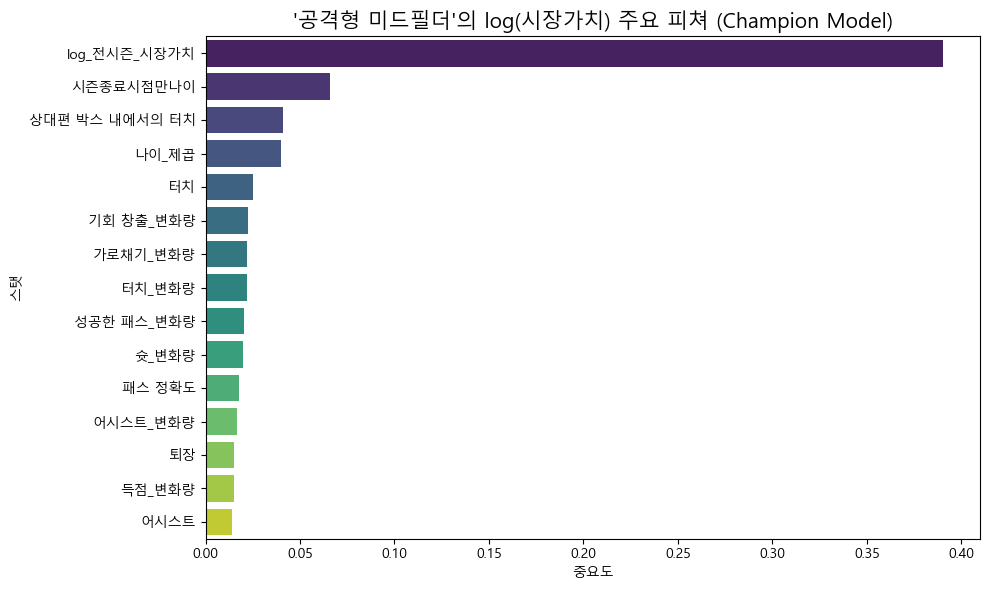


******************************
  예측 오차 심층 분석 - 공격형 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8296  philippe coutinho         29    63000000.0  19500000.00   43707528.0   
2994        nabil fekir         26    65000000.0  36000000.00   56773700.0   
8521    roberto firmino         31    59000000.0  22666666.67   41453424.0   
476     james rodriguez         27    66250000.0  57500000.00   75412600.0   
6067        amine harit         24    14500000.0   9500000.00   25923528.0   

        예측_오차_EUR  
8296  24207528.00  
2994  20773700.00  
8521  18786757.33  
476   17912600.00  
6067  16423528.00  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
5399           neymar         28   170000000.0  144000000.0  102520744.0   
3875             gavi         18    46250000.0   83333333.0   42304492.0   
7197  kevin de bruyne         26    650

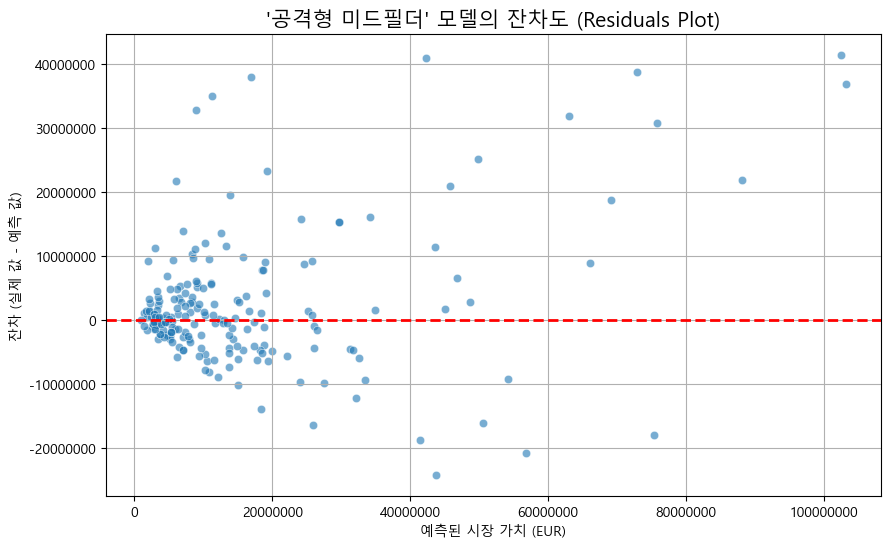


✨ 포지션 그룹 최종 분석 (Champion Model): 수비형 미드필더 ✨
'수비형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 70.13%
  - 평균 예측 오차 (RMSE): 11,043,373 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.342765    log_전시즌_시장가치
2     0.122448       시즌종료시점만나이
3     0.094127           나이_제곱
4     0.031016          터치_변화량
5     0.028543              터치
6     0.026718      성공한 패스_변화량
7     0.016468  상대편 박스 내에서의 터치
8     0.012371            막힌 슛
9     0.012277         볼 경합 성공
10    0.012067       공격 지역 점유율
11    0.011965              반칙
12    0.011837          성공한 패스
13    0.011759          태클_변화량
14    0.011522        슛_대비_득점율
15    0.011259       볼 경합 성공 %


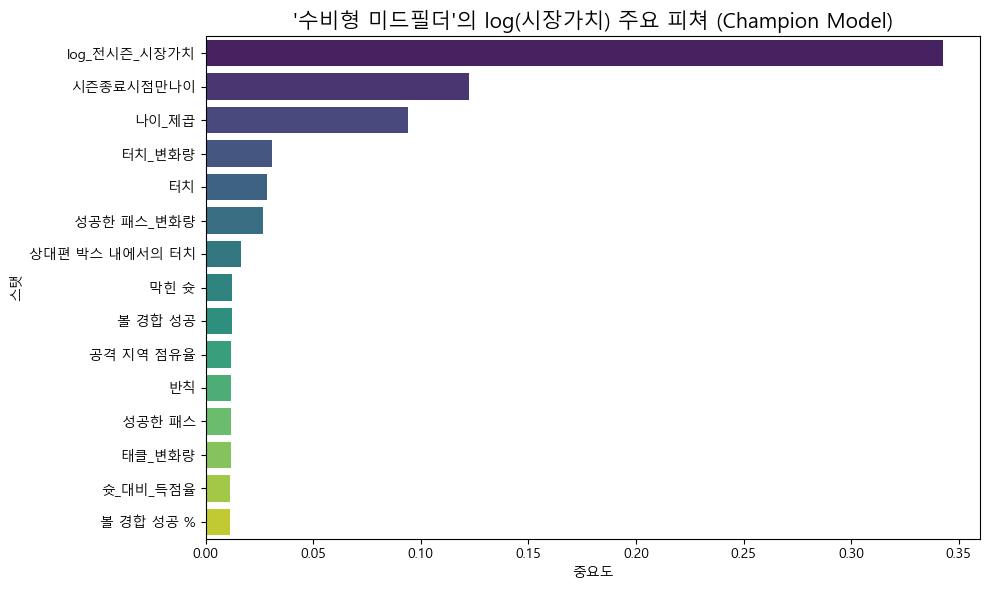


******************************
  예측 오차 심층 분석 - 수비형 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                     선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
1720       leon goretzka         29    55000000.0   33333333.0   55183456.0   
9284               allan         26           0.0     200000.0   15374804.0   
1402     marcel sabitzer         28    42000000.0   24000000.0   38820784.0   
1265  santiago ascacibar         25    18750000.0    7000000.0   20405208.0   
1949      joshua kimmich         30    61666667.0   47500000.0   60507952.0   

       예측_오차_EUR  
1720  21850123.0  
9284  15174804.0  
1402  14820784.0  
1265  13405208.0  
1949  13007952.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                      선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8367                allan         31   105000000.0  150000000.0   28036860.0   
3309            josé mari         23           0.0   63750000.0    3497943.5   
8995  alexis mac allister  

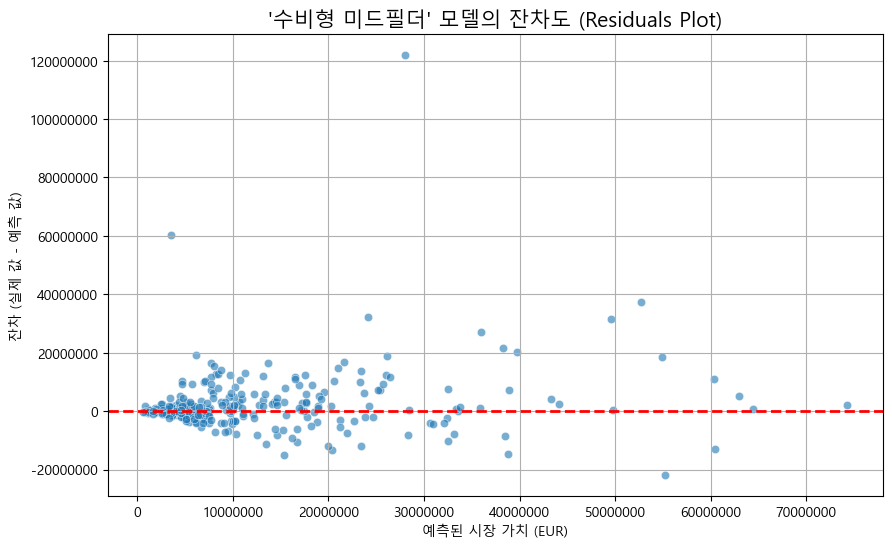


✨ 포지션 그룹 최종 분석 (Champion Model): 스트라이커 ✨
'스트라이커' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 75.53%
  - 평균 예측 오차 (RMSE): 9,495,750 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.376517    log_전시즌_시장가치
2     0.079451       시즌종료시점만나이
3     0.059436           나이_제곱
4     0.033001  상대편 박스 내에서의 터치
5     0.023315          득점_변화량
6     0.022177       나이x득점_변화량
7     0.021780        슛_대비_득점율
8     0.021426              반칙
9     0.017995          터치_변화량
10    0.015717              퇴장
11    0.014967        어시스트_변화량
12    0.014948           슛_변화량
13    0.014411      공중 볼 경합 성공
14    0.014190      성공한 패스_변화량
15    0.013828       기회 창출_변화량


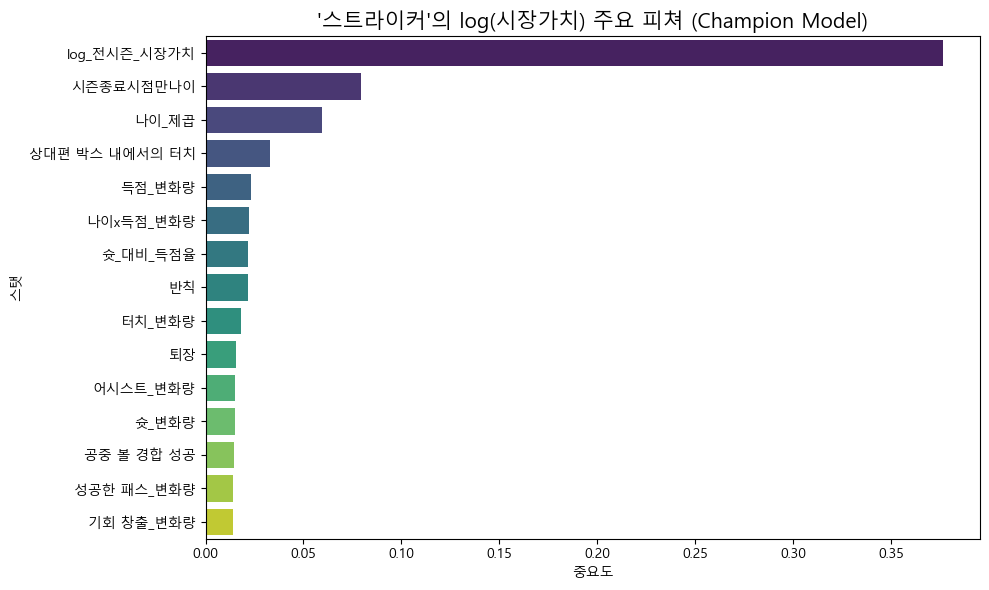


******************************
  예측 오차 심층 분석 - 스트라이커
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                             선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  \
10769            patrick cutrone         24   29000000.00    5250000.0   
1808               patrik schick         28   45000000.00   22000000.0   
10277                 joao pedro         19   17666666.67   10500000.0   
6505   pierre-emerick aubameyang         34   37500000.00    4500000.0   
1174          robert lewandowski         33   60000000.00   47500000.0   

       예측_시장가치_EUR   예측_오차_EUR  
10769   24494096.0  19244096.0  
1808    38277360.0  16277360.0  
10277   25414168.0  14914168.0  
6505    18776980.0  14276980.0  
1174    61326504.0  13826504.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                            선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  \
2461               lionel messi         30   120000000.0  180000000.0   
8965              evan ferguson         19           0.0   60000000.0 

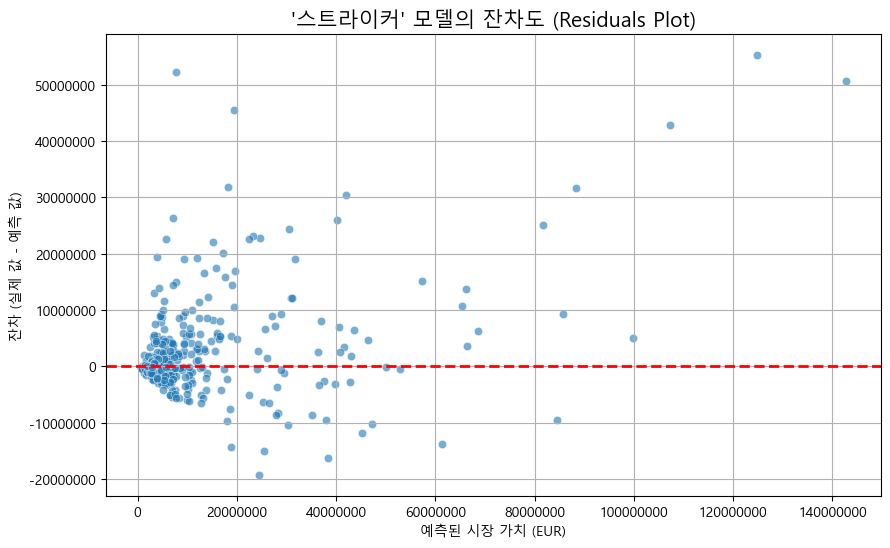


✨ 포지션 그룹 최종 분석 (Champion Model): 윙어 ✨
'윙어' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 73.79%
  - 평균 예측 오차 (RMSE): 13,607,486 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.210922    log_전시즌_시장가치
2     0.120981  상대편 박스 내에서의 터치
3     0.065901       시즌종료시점만나이
4     0.036915           나이_제곱
5     0.034200        슛_대비_득점율
6     0.029235      성공한 패스_변화량
7     0.025440              퇴장
8     0.021261              회복
9     0.020185          득점_변화량
10    0.019489              반칙
11    0.018646          성공한 패스
12    0.017909          태클_변화량
13    0.017449              터치
14    0.016409           기회 창출
15    0.015387           슛_변화량


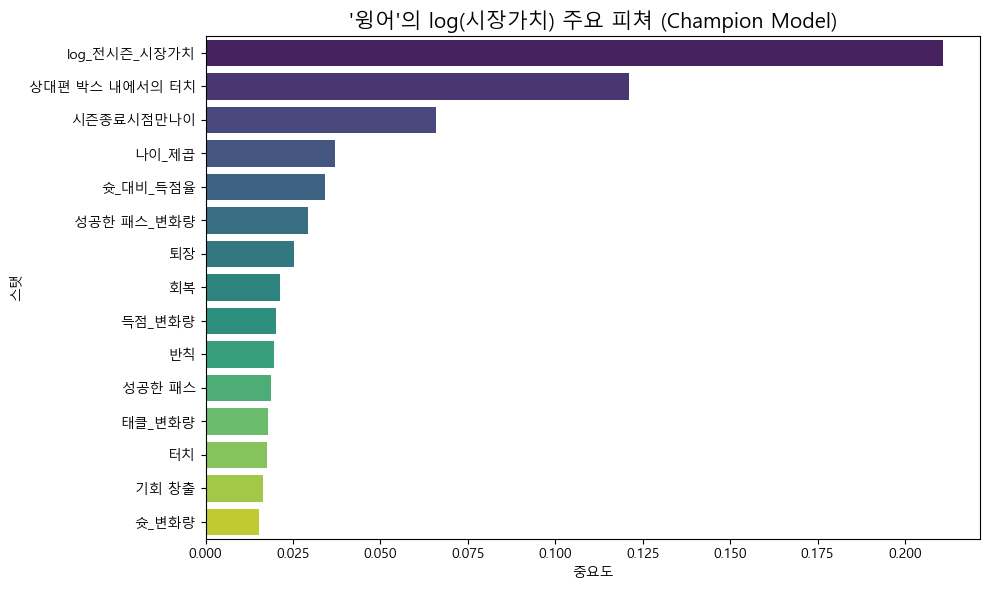


******************************
  예측 오차 심층 분석 - 윙어
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                   선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4604    arnaut danjuma         28    41250000.0    5666667.0   32000600.0   
8727     mohamed salah         31    71666667.0   60000000.0   86268576.0   
3323  samuel chukwueze         22    28500000.0   21666667.0   43415396.0   
1492       timo werner         27    45500000.0   25000000.0   44120712.0   
5785        rony lopes         25    26500000.0    8333333.0   20979060.0   

       예측_오차_EUR  
4604  26333933.0  
8727  26268576.0  
3323  21748729.0  
1492  19120712.0  
5785  12645727.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4094  vinicius junior         23   130000000.0  165000000.0   66520040.0   
700      jadon sancho         20    63000000.0  122333333.0   51328932.0   
8988      bukayo saka         23   130000000.0  150000000

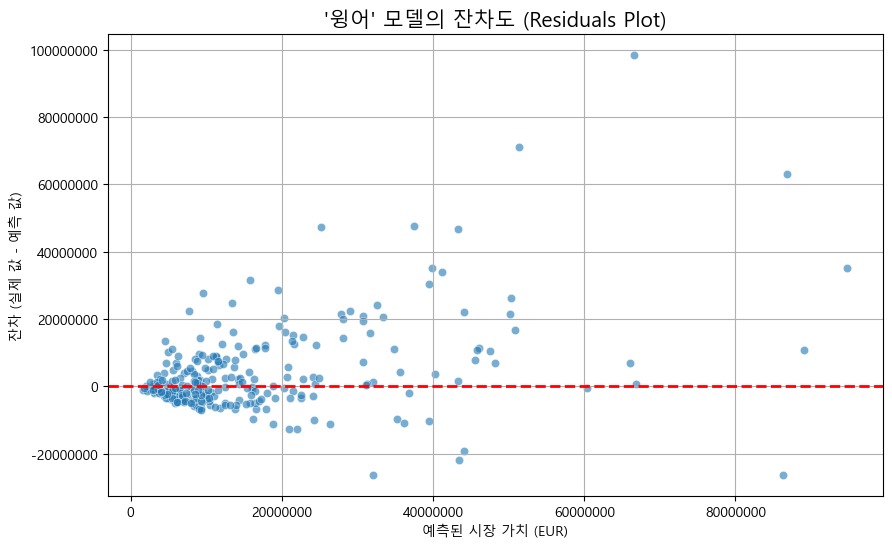


✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 미드필더 ✨
'중앙 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 78.46%
  - 평균 예측 오차 (RMSE): 7,123,498 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.353706    log_전시즌_시장가치
2     0.114473       시즌종료시점만나이
3     0.050043           나이_제곱
4     0.040894          성공한 패스
5     0.039600              터치
6     0.030014  상대편 박스 내에서의 터치
7     0.029194      성공한 패스_변화량
8     0.024806        가로채기_변화량
9     0.019266          터치_변화량
10    0.015517          득점_변화량
11    0.013883              득점
12    0.013760        슛_대비_득점율
13    0.012785            가로채기
14    0.012377          패스 정확도
15    0.011910       볼 경합 성공 %


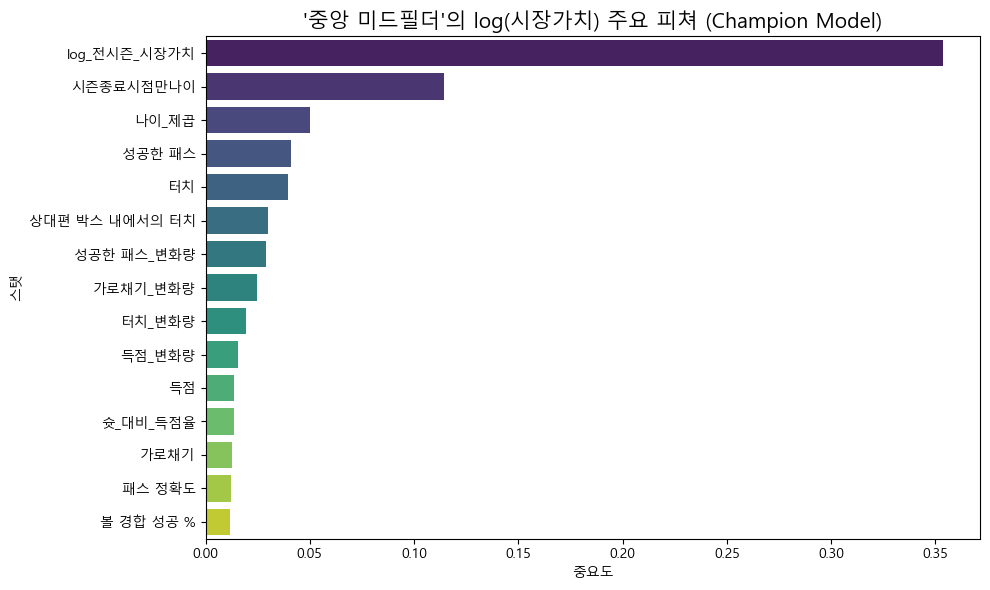


******************************
  예측 오차 심층 분석 - 중앙 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                       선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
6262      corentin tolisso         28    40000000.0   14000000.0   38942260.0   
7983              jorginho         29    58500000.0   45000000.0   64602192.0   
8819        harvey elliott         21    35000000.0   33333333.0   49044124.0   
4054         pablo barrios         19           0.0    2650000.0   13984240.0   
10025  roberto gagliardini         26    20000000.0   13500000.0   24229564.0   

        예측_오차_EUR  
6262   24942260.0  
7983   19602192.0  
8819   15710791.0  
4054   11334240.0  
10025  10729564.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
2236      saul niguez         22          0.00   37500000.0    4923698.5   
2760          rodrigo         21   22500000.00   57500000.0   25132848.0   
2210      luka modric 

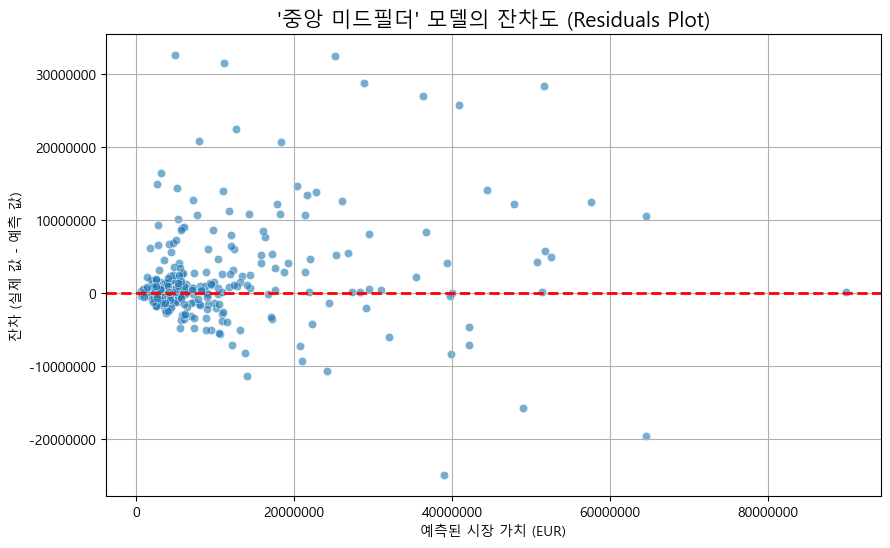


✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 수비수 ✨
'중앙 수비수' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 75.84%
  - 평균 예측 오차 (RMSE): 7,510,670 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.156916    log_전시즌_시장가치
2     0.121248           나이_제곱
3     0.118125       시즌종료시점만나이
4     0.052527          성공한 패스
5     0.040831              터치
6     0.031837  상대편 박스 내에서의 터치
7     0.026194          터치_변화량
8     0.023550      성공한 패스_변화량
9     0.018572          패스 정확도
10    0.017469      공중 볼 경합 성공
11    0.016764          태클_변화량
12    0.016282        가로채기_변화량
13    0.015349       볼 경합 성공 %
14    0.015283          득점_변화량
15    0.015094           슛_변화량


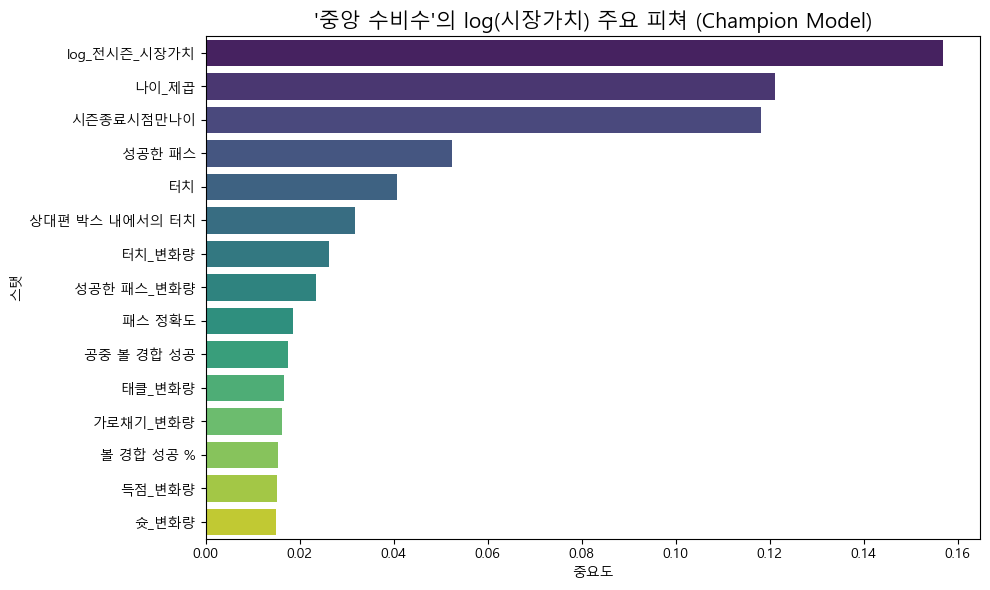


******************************
  예측 오차 심층 분석 - 중앙 수비수
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                     선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8238     aymeric laporte         28    67500000.0   45000000.0   70337608.0   
3316     clément lenglet         25    54000000.0   35000000.0   53707372.0   
8118           eric dier         27    40000000.0   23500000.0   37867944.0   
10635  nikola milenkovic         24    27000000.0   21500000.0   35507548.0   
54           niklas süle         21           0.0   22500000.0   36175152.0   

        예측_오차_EUR  
8238   25337608.0  
3316   18707372.0  
8118   14367944.0  
10635  14007548.0  
54     13675152.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                      선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
3397               josema         24          0.00   63750000.0    2874633.5   
2923             bernardo         24   45000000.00   76250000.0   36629924.0   
3465                rob

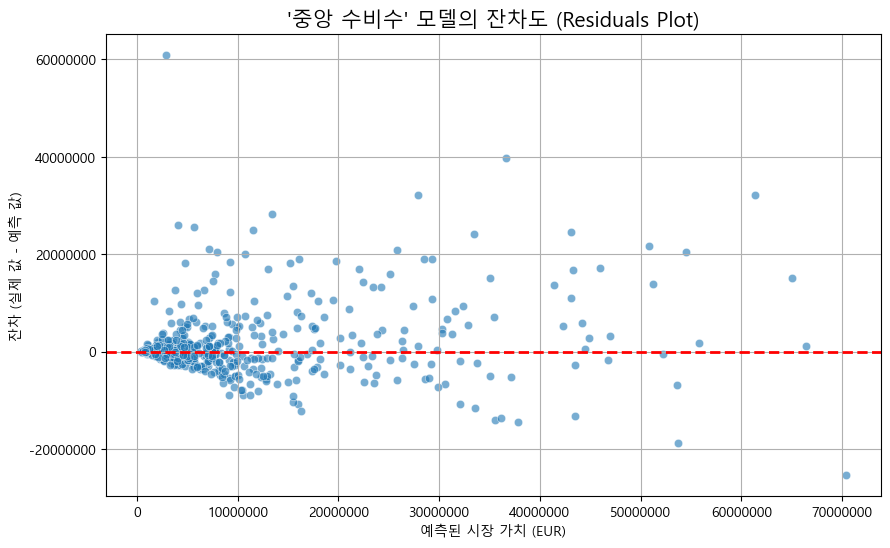


✨ 포지션 그룹 최종 분석 (Champion Model): 측면 미드필더 ✨
'측면 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 52.50%
  - 평균 예측 오차 (RMSE): 6,736,547 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.361180    log_전시즌_시장가치
2     0.113373       시즌종료시점만나이
3     0.113330           나이_제곱
4     0.042170  상대편 박스 내에서의 터치
5     0.028923         페널티킥 받음
6     0.021879        어시스트_변화량
7     0.021804          성공한 패스
8     0.016467       기회 창출_변화량
9     0.014154         페널티킥 허용
10    0.013640      공중 볼 경합 성공
11    0.013515            볼 뺏김
12    0.013502              퇴장
13    0.013207          득점_변화량
14    0.012672           슛_변화량
15    0.010854      성공한 패스_변화량


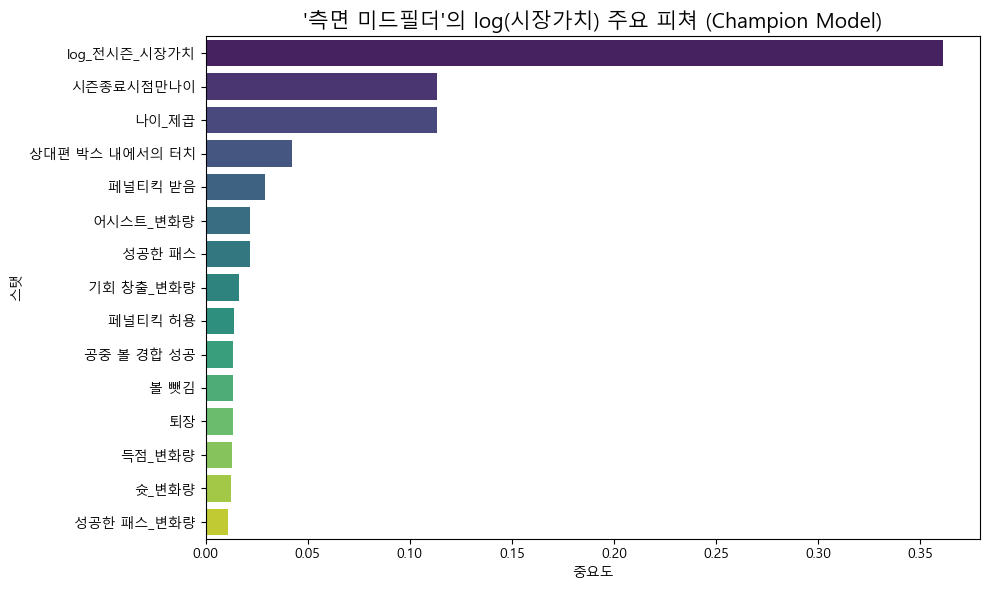


******************************
  예측 오차 심층 분석 - 측면 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                   선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
6349      aaron ramsey         32    18666667.0    2750000.0  11511089.00   
6318        adam ounas         26     8000000.0    7500000.0  14282811.00   
1444        borna sosa         25    21500000.0   16750000.0  22649664.00   
4047  valery fernández         23           0.0    1500000.0   6927634.00   
4457       yéremi pino         22      125000.0      37500.0   3125463.25   

       예측_오차_EUR  
6349  8761089.00  
6318  6782811.00  
1444  5899664.00  
4047  5427634.00  
4457  3087963.25  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                   선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4945    julian draxler         24           0.0   35000000.0   6560146.50   
8736   conor gallagher         24    31333333.0   45000000.0  22410780.00   
2073      antonio nusa         20           0.0  

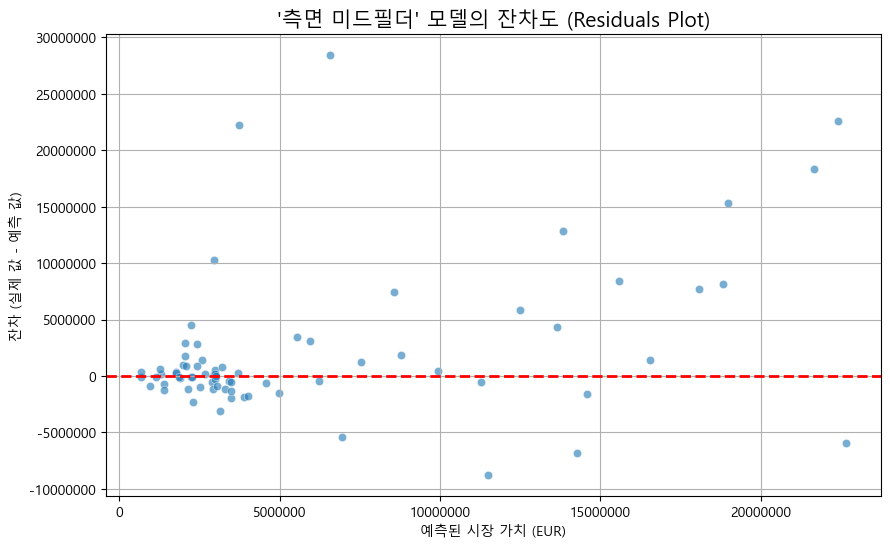


✨ 포지션 그룹 최종 분석 (Champion Model): 측면 수비수 ✨
'측면 수비수' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 76.48%
  - 평균 예측 오차 (RMSE): 6,048,350 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.292033    log_전시즌_시장가치
2     0.102866       시즌종료시점만나이
3     0.077174           나이_제곱
4     0.064688  상대편 박스 내에서의 터치
5     0.045066              터치
6     0.042852          성공한 패스
7     0.028190      성공한 패스_변화량
8     0.020409          터치_변화량
9     0.019124       기회 창출_변화량
10    0.017886        가로채기_변화량
11    0.013983           슛_변화량
12    0.011920           기회 창출
13    0.011838          태클_변화량
14    0.011755      InjuryDays
15    0.011386         페널티킥 받음


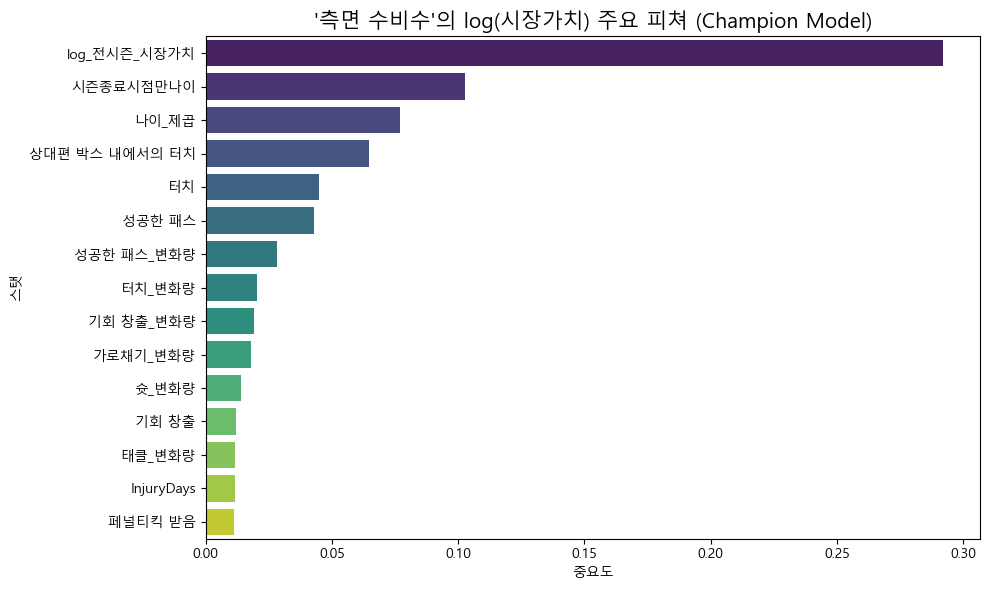


******************************
  예측 오차 심층 분석 - 측면 수비수
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
484   raphaël guerreiro         25    18666667.0   21000000.0   35909588.0   
3233      lucas vázquez         29    25000000.0   13333333.0   27345004.0   
4675     thomas meunier         25           0.0    8250000.0   20654680.0   
3540    daniel carvajal         30    45000000.0   20250000.0   30205296.0   
1307      konrad laimer         25    26250000.0   27000000.0   36043808.0   

       예측_오차_EUR  
484   14909588.0  
3233  14011671.0  
4675  12404680.0  
3540   9955296.0  
1307   9043808.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                         선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  \
7710  trent alexander-arnold         21    52500000.0  106333333.0   
1516          josko gvardiol         21    30000000.0   67500000.0   
953          alphonso davies         20    39166667.0   75000000.

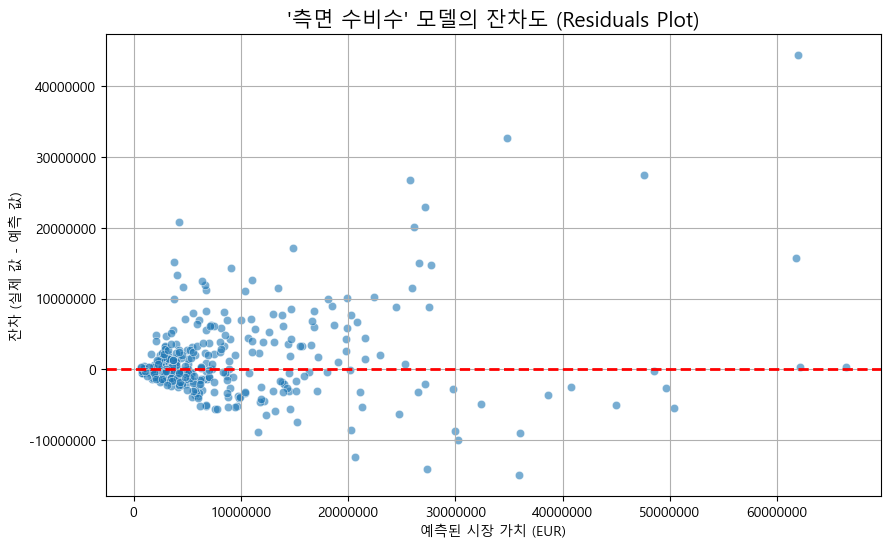

In [30]:
print("\n" + "="*80)
print("✨ 모든 포지션 최적화 완료! 최종 모델 학습 및 분석 시작 ✨")
print("="*80)

final_results_storage = {}

position_groups = sorted(df['포지션_그룹'].unique())
for group in position_groups:
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최종 분석 (Champion Model): {group} ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: 
        print(f"'{group}' 그룹은 데이터 수가 적어 분석을 건너뜁니다.")
        continue
    
    y = group_df['log_현재_시장가치']
    
    # 삭제할 컬럼 재정의 (위와 동일)
    possible_drop_cols = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ]
    for stat in stats_for_change:
        possible_drop_cols.append(f'전시즌_{stat}')
    cols_to_drop = [c for c in possible_drop_cols if c in group_df.columns]

    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"'{group}' 포지션의 최종 챔피언 모델을 학습합니다...")
    champion_params = champion_params_storage.get(group)
    if not champion_params:
        print(f"'{group}'에 대한 최적 파라미터를 찾을 수 없어 건너뜁니다.")
        continue
    
    final_model = XGBRegressor(objective='reg:squarederror', **champion_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train_scaled, y_train, verbose=False)

    # --- 최종 모델 평가 및 오차 분석 ---
    log_y_pred = final_model.predict(X_test_scaled)
    y_pred = np.expm1(log_y_pred)
    y_test_orig = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test, log_y_pred) 
    
    print(f"\n[📊 **챔피언 모델** 성능 평가]")
    print(f"  - 모델 설명력 (R-squared): {r2:.2%}")
    print(f"  - 평균 예측 오차 (RMSE): {rmse:,.0f} EUR")

    # 피쳐 중요도
    importances = final_model.feature_importances_
    feature_names = X.columns
    imp_df = pd.DataFrame(sorted(zip(importances, feature_names), reverse=True), columns=['Importance', 'Feature']).head(15)
    print(f"\n[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]")
    imp_df_display = imp_df.copy()
    imp_df_display.index = np.arange(1, len(imp_df_display) + 1)
    print(imp_df_display)
    plt.figure(figsize=(10, 6)); sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis'); plt.title(f"'{group}'의 log(시장가치) 주요 피쳐 (Champion Model)", fontsize=15); plt.xlabel('중요도'); plt.ylabel('스탯'); plt.tight_layout(); plt.show()
    
    # 오차 분석
    results_df = X_test.copy(); results_df['선수명'] = df.loc[X_test.index, 'name_key']; results_df['전시즌_시장가치_EUR'] = df.loc[X_test.index, '전시즌_시장가치_EUR']; results_df['실제_시장가치_EUR'] = y_test_orig; results_df['예측_시장가치_EUR'] = pd.Series(y_pred, index=X_test.index); results_df['예측_오차_EUR'] = results_df['예측_시장가치_EUR'] - results_df['실제_시장가치_EUR']; analysis_cols = ['선수명', '시즌종료시점만나이', '전시즌_시장가치_EUR', '실제_시장가치_EUR', '예측_시장가치_EUR', '예측_오차_EUR']; error_analysis_df = results_df[analysis_cols].copy(); print("\n" + "*"*30); print(f"  예측 오차 심층 분석 - {group}"); print("*"*30); print("\n[⬆️ 모델이 가장 과대평가한 선수 TOP 5]"); print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=False).head(5)); print("\n[⬇️ 모델이 가장 과소평가한 선수 TOP 5]"); print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=True).head(5)); print("\n[🎯 모델이 가장 정확하게 예측한 선수 TOP 5]"); most_accurate = error_analysis_df.copy(); most_accurate['절대오차'] = most_accurate['예측_오차_EUR'].abs(); print(most_accurate.sort_values(by='절대오차', ascending=True).head(5).drop(columns='절대오차'));
    
    # 잔차도
    residuals = y_test_orig - y_pred; plt.figure(figsize=(10, 6)); sns.scatterplot(x=y_pred, y=residuals, alpha=0.6); plt.axhline(y=0, color='r', linestyle='--', lw=2); plt.title(f"'{group}' 모델의 잔차도 (Residuals Plot)", fontsize=15); plt.xlabel("예측된 시장 가치 (EUR)"); plt.ylabel("잔차 (실제 값 - 예측 값)"); plt.ticklabel_format(style='plain', axis='both'); plt.grid(True); plt.show()
    
    final_results_storage[group] = {
        'model': final_model, 'scaler': scaler, 'X_columns': X.columns,
        'r2': r2, 'rmse': rmse, 'feature_importance': imp_df,
        'error_analysis': error_analysis_df
    }

In [11]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
import optuna
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import warnings

# 경고 메시지 제어 (너무 많이 뜨는 것 방지)
warnings.filterwarnings('ignore', category=UserWarning)

def objective_lgbm(trial, group, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 7, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }
    
    model = LGBMRegressor(**params)
    
    # 조기 종료 설정
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    preds = model.predict(X_val)
    r2 = r2_score(y_val, preds)
    return r2

# --- 메인 실행 루프 ---

print("\n" + "="*80)
print("✨ LightGBM 모델 최적화 (Warning 해결 버전) ✨")
print("="*80)

lgbm_results = {}
position_groups = sorted(df['포지션_그룹'].unique())

for group in position_groups:
    print(f"\n[⚽ 포지션 그룹: {group}]")
    
    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: 
        continue

    # 데이터 준비
    y = group_df['log_현재_시장가치']
    
    possible_drop_cols = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ]
    if 'stats_for_change' in globals():
        for stat in stats_for_change:
            possible_drop_cols.append(f'전시즌_{stat}')
            
    cols_to_drop = [c for c in possible_drop_cols if c in group_df.columns]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- [수정된 부분] 스케일링 후 DataFrame으로 복구 ---
    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train)
    X_test_scaled_np = scaler.transform(X_test)
    
    # Numpy Array -> Pandas DataFrame (컬럼명 복구)
    X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)
    # ------------------------------------------------
    
    print(f"  -> 하이퍼파라미터 튜닝 진행 중...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_lgbm(trial, group, X_train_scaled, y_train, X_test_scaled, y_test), n_trials=30)
    
    print(f"\n  🎯 [최고 R-squared: {study.best_value:.4f}] 달성 시 파라미터:")
    print("-" * 50)
    for key, value in study.best_params.items():
        print(f"    • {key.ljust(20)} : {value}")
    print("-" * 50)

    # 최적 모델 학습
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbosity'] = -1
    
    final_model = LGBMRegressor(**best_params)
    final_model.fit(X_train_scaled, y_train)
    
    log_y_pred = final_model.predict(X_test_scaled)
    y_pred = np.expm1(log_y_pred)
    y_test_orig = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test, log_y_pred)
    
    print(f"  📊 최종 검증셋 성능 -> RMSE: {rmse:,.0f} EUR | R2: {r2:.2%}")
    
    lgbm_results[group] = {
        'model': final_model, 
        'r2': r2, 
        'rmse': rmse, 
        'best_params': best_params
    }

print("\n✅ 전체 분석 완료.")


✨ LightGBM 모델 최적화 (Warning 해결 버전) ✨

[⚽ 포지션 그룹: 공격형 미드필더]
  -> 하이퍼파라미터 튜닝 진행 중...

  🎯 [최고 R-squared: 0.6868] 달성 시 파라미터:
--------------------------------------------------
    • n_estimators         : 1000
    • learning_rate        : 0.015867443498727818
    • num_leaves           : 42
    • max_depth            : 9
    • min_child_samples    : 26
    • subsample            : 0.7040121176737311
    • colsample_bytree     : 0.6252487371956483
    • reg_alpha            : 7.539914899079217e-05
    • reg_lambda           : 0.034311303485128515
--------------------------------------------------
  📊 최종 검증셋 성능 -> RMSE: 11,097,140 EUR | R2: 68.64%

[⚽ 포지션 그룹: 수비형 미드필더]
  -> 하이퍼파라미터 튜닝 진행 중...

  🎯 [최고 R-squared: 0.6989] 달성 시 파라미터:
--------------------------------------------------
    • n_estimators         : 1500
    • learning_rate        : 0.022058611699211018
    • num_leaves           : 49
    • max_depth            : 11
    • min_child_samples    : 38
    • subsample            : 0.88